In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("knovist_technologies_conversion_and_sales_data_modified.csv")

In [ ]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10032 entries, 0 to 10031
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 10032 non-null  object 
 1   contact_number       10032 non-null  int64  
 2   Contact_email        10032 non-null  object 
 3   creation_date        10032 non-null  object 
 4   first_call_attempt   8777 non-null   object 
 5   lead_status          10032 non-null  object 
 6   lead_stage           10032 non-null  object 
 7   lead_tag             6400 non-null   object 
 8   assigned_to          10032 non-null  object 
 9   last_call_date       8777 non-null   object 
 10  last_call_time       8777 non-null   object 
 11  references           0 non-null      float64
 12  campaign_name        10032 non-null  object 
 13  source_type          10032 non-null  object 
 14  source_name          10032 non-null  object 
 15  Total Leads          10032 non-null 

In [ ]:
df = df.drop(
[
'Name',
'contact_number',
'Contact_email',
'references'
],
axis=1
)

In [ ]:
df.columns

Index(['creation_date', 'first_call_attempt', 'lead_status', 'lead_stage',
       'lead_tag', 'assigned_to', 'last_call_date', 'last_call_time',
       'campaign_name', 'source_type', 'source_name', 'Total Leads', 'Sales',
       'Conversion Rate (%)', 'Cost per Lead', 'Total Cost'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
creation_date,0
first_call_attempt,1255
lead_status,0
lead_stage,0
lead_tag,3632
assigned_to,0
last_call_date,1255
last_call_time,1255
campaign_name,0
source_type,0


In [ ]:
df['lead_tag'] = df['lead_tag'].fillna('Unknown')

df['first_call_attempt'] = df['first_call_attempt'].fillna('No Call')

df['last_call_date'] = df['last_call_date'].fillna('No Date')

df['last_call_time'] = df['last_call_time'].fillna('No Time')
df['Cost per Lead'] = df['Cost per Lead'].fillna(df['Cost per Lead'].median())

df['Total Cost'] = df['Total Cost'].fillna(df['Total Cost'].median())

In [ ]:
df.isnull().sum()

,0
creation_date,0
first_call_attempt,0
lead_status,0
lead_stage,0
lead_tag,0
assigned_to,0
last_call_date,0
last_call_time,0
campaign_name,0
source_type,0


In [ ]:
df['Converted'] = np.where(
df['lead_stage']=='CONVERTED',
1,
0
)

In [ ]:
df['Converted'].value_counts()

,count
Converted,
0,9895
1,137


In [ ]:
df = df.drop('lead_stage',axis=1)

In [ ]:
df['creation_date'] = df['creation_date'].astype(str)

df['last_call_date'] = df['last_call_date'].astype(str)

df['last_call_time'] = df['last_call_time'].astype(str)

df['first_call_attempt'] = df['first_call_attempt'].astype(str)

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['creation_date', 'first_call_attempt', 'lead_status', 'lead_tag',
       'assigned_to', 'last_call_date', 'last_call_time', 'campaign_name',
       'source_type', 'source_name'],
      dtype='object')


In [ ]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df = df.replace([np.inf,-np.inf],np.nan)

df = df.fillna(0)

In [ ]:
print(df.isnull().sum().sum())


0


In [ ]:
X = df.drop('Converted',axis=1)

y = df['Converted']

In [ ]:
print(X.isnull().sum().sum())

0


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(8025, 15)
(2007, 15)


In [ ]:
lr = LogisticRegression(
max_iter=1000
)

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print("Accuracy:",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred))
print("Recall:",recall_score(y_test,lr_pred))
print("F1:",f1_score(y_test,lr_pred))

Accuracy: 0.9965122072745392
Precision: 0.8846153846153846
Recall: 0.8518518518518519
F1: 0.8679245283018868


In [ ]:
dt = DecisionTreeClassifier(
random_state=42
)

dt.fit(X_train,y_train)

dt_pred = dt.predict(X_test)

In [ ]:
print("Accuracy:",accuracy_score(y_test,dt_pred))
print("Precision:",precision_score(y_test,dt_pred))
print("Recall:",recall_score(y_test,dt_pred))
print("F1:",f1_score(y_test,dt_pred))

Accuracy: 0.9990034877927254
Precision: 1.0
Recall: 0.9259259259259259
F1: 0.9615384615384616


In [ ]:
rf = RandomForestClassifier(
n_estimators=200,
random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [ ]:
print("Accuracy:",accuracy_score(y_test,rf_pred))
print("Precision:",precision_score(y_test,rf_pred))
print("Recall:",recall_score(y_test,rf_pred))
print("F1:",f1_score(y_test,rf_pred))

Accuracy: 0.9990034877927254
Precision: 1.0
Recall: 0.9259259259259259
F1: 0.9615384615384616


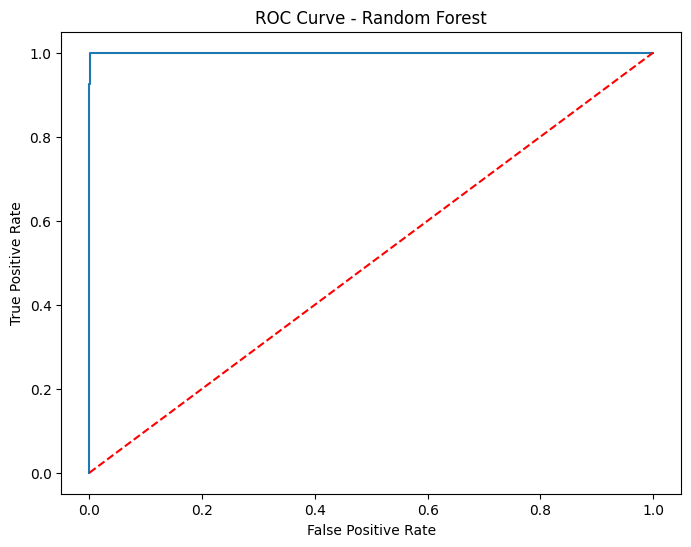

In [ ]:
from sklearn.metrics import roc_curve

rf_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

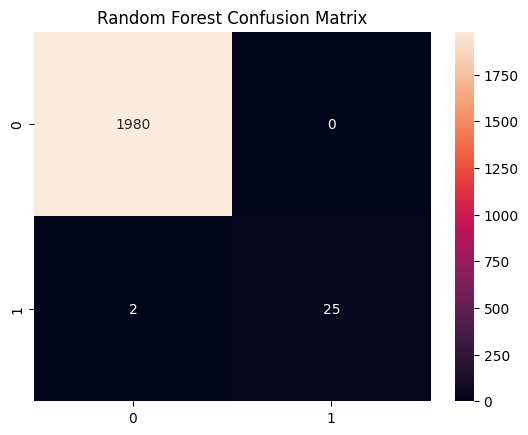

In [ ]:
cm = confusion_matrix(
y_test,
rf_pred
)

sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.title(
'Random Forest Confusion Matrix'
)

plt.show()

In [ ]:
importance = pd.DataFrame(
{
'Feature':X.columns,
'Importance':rf.feature_importances_
}
)

importance = importance.sort_values(
by='Importance',
ascending=False
)

print(importance.head(10))

                Feature  Importance
2           lead_status    0.304484
3              lead_tag    0.273080
5        last_call_date    0.061025
1    first_call_attempt    0.052551
6        last_call_time    0.051982
4           assigned_to    0.049081
0         creation_date    0.033057
12  Conversion Rate (%)    0.031248
14           Total Cost    0.030379
7         campaign_name    0.025116


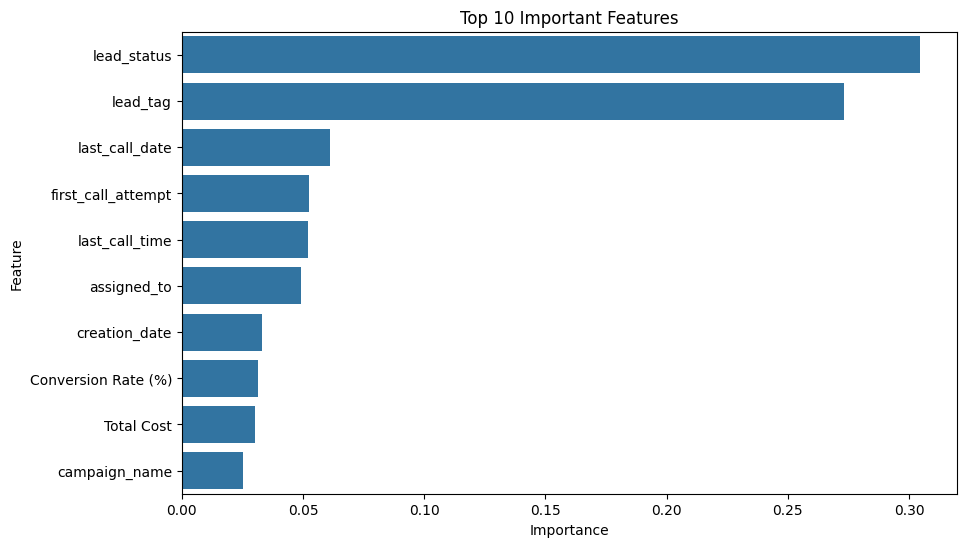

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
data=importance.head(10),
x='Importance',
y='Feature'
)

plt.title(
'Top 10 Important Features'
)

plt.show()

In [ ]:
results = pd.DataFrame({

'Model':
['Logistic Regression',
 'Decision Tree',
 'Random Forest'],

'Accuracy':
[
accuracy_score(y_test,lr_pred),
accuracy_score(y_test,dt_pred),
accuracy_score(y_test,rf_pred)
],

'Precision':
[
precision_score(y_test,lr_pred),
precision_score(y_test,dt_pred),
precision_score(y_test,rf_pred)
],

'Recall':
[
recall_score(y_test,lr_pred),
recall_score(y_test,dt_pred),
recall_score(y_test,rf_pred)
],

'F1':
[
f1_score(y_test,lr_pred),
f1_score(y_test,dt_pred),
f1_score(y_test,rf_pred)
]

})

results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.996512,0.884615,0.851852,0.867925
1,Decision Tree,0.999003,1.000000,0.925926,0.961538
2,Random Forest,0.999003,1.000000,0.925926,0.961538


In [ ]:
sample_lead = X_test.iloc[[0]]

prediction = rf.predict(sample_lead)

probability = rf.predict_proba(sample_lead)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[1. 0.]]
